In [1]:
import random
import sys

import matplotlib.pyplot as plt
import numpy as np

from collections import defaultdict, Counter
from IPython.display import clear_output

import glob

# sys.path.append("/orcd/data/jhm/001/om2/bjmedina/memory/utils/")
# from sequence_utils import *

In [ ]:
# Shared sequence generation utilities (modularized)
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from collections import defaultdict, Counter
import glob
import json
import os
import random
import re
import stat

import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output
from utils.sequence_utils import ISISequence, StimulusManager, save_all_sequences


In [ ]:
# StimulusManager definition moved to utils.sequence_utils.
# Keeping this placeholder cell so downstream cell numbers remain stable.


In [18]:
len_exp = 120 # needs to be a multiple of 3 (2 non-repeat, 1 repeat trials -> three trials)

unique_stim_needed = int((len_exp/3)*2)
ISI_conditions = [-1, 0, 1, 2, 4, 8, 16, 32, 64] 

total_pairs_of_repeat_stimuli = int(len_exp / 3) 
min_pairs_per_isi = int(total_pairs_of_repeat_stimuli / (len(ISI_conditions) - 1)) #len(ISI_conditions) - 1 because we don't count the -1 isi condition (nonrepeats)

manager = ISISequence(length=len_exp, 
                      isi_values=ISI_conditions, 
                      seed=15)

# bolivia => seed 14
# env sounds => seed 15
# globalized music => seed 16
# atextus => seed 17

n_gen_seqs = 176
manager.generate_n(n=n_gen_seqs, 
                   min_pairs_per_isi=min_pairs_per_isi)


#manager.toggle_debug()

Aggregate ISI usage across all sequences:
  ISI -1: 7040
  ISI 0: 1760
  ISI 1: 1760
  ISI 2: 1760
  ISI 4: 1760
  ISI 8: 1760
  ISI 16: 1760
  ISI 32: 1760
  ISI 64: 1760


In [19]:
# len_exp = 120 # needs to be a multiple of 3 (2 non-repeat, 1 repeat trials -> three trials)

# unique_stim_needed = int((len_exp/3)*2)
# ISI_conditions = [-1, 0, 1, 2, 4, 8] 

# total_pairs_of_repeat_stimuli = int(len_exp / 3) 
# min_pairs_per_isi = int(total_pairs_of_repeat_stimuli / (len(ISI_conditions) - 1)) #len(ISI_conditions) - 1 because we don't count the -1 isi condition (nonrepeats)

# manager = ISISequence(length=len_exp, 
#                       isi_values=ISI_conditions, 
#                       seed=14)


# #manager.toggle_debug()

In [20]:
# n_gen_seqs = 120
# manager.generate_n(n=n_gen_seqs, 
#                    min_pairs_per_isi=min_pairs_per_isi) #generates n many sequnces
# #print(len(manager.sequences))

In [21]:
manager.check_balance()

Total ISI counts across sequences:
ISI 0: 1760
ISI 1: 1760
ISI 2: 1760
ISI 4: 1760
ISI 8: 1760
ISI 16: 1760
ISI 32: 1760
ISI 64: 1760
✅ ISI conditions are statistically balanced (within 1 std deviation).


In [22]:
import re
import glob
import json

# def extract_index(path):
#     # Extract the first number that appears after "mem_stim_num"
#     match = re.search(r'mem_stim_num(\d+)_', path)
#     return int(match.group(1)) if match else float('inf')  # fallback just in case


# # bolivia
# pairs_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p2"

# env_sounds
pairs_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025"

# # globalized music
# pairs_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80"

# # atexts
#pairs_path = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025"

with open(pairs_path + "/filenames.json") as f:
    sound_types_json = json.load(f)
    

#all_sound_pairs = sorted(glob.glob(pairs_path + "/ mem_exp_stim_*.wav"))
all_sounds = sorted(glob.glob(pairs_path + "/mem_stim_*.wav"))
print(len(all_sounds))
print(sound_types_json[-1])#print(total_pairs_of_repeat_stimuli, len(all_sounds))

91
{'orig_path': '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_p2/mem_stim_30.wav', 'stim_path': '/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/mem_stim_89.wav', 'filename': 'mem_stim_89.wav', 'onset': 0.0, 'type': 'nature'}


In [23]:
#all_sound_pairs = sorted(all_sound_pairs, key=extract_index)
#print(*all_sound_pairs, sep="\n")
#print(*all_sound_pairs, sep="\n")

all_sounds = sorted(all_sounds)
#print(*all_sounds, sep="\n")

In [10]:
unique_stim_needed

80

In [24]:
# env sounds + bolivia = seed 14
# globalized music + atexts = seed 16
sm = StimulusManager(stimulus_ids=all_sounds[:unique_stim_needed],#np.arange(total_pairs_of_repeat_stimuli*2, dtype=np.int32),
                     isi_values=ISI_conditions, 
                     length=len_exp, 
                     seed=14,
                     shuffle=True) ###### VERY IMPORTANT
for j in range(n_gen_seqs):

    seq, pairs = manager.get_sequence_and_isi_pairings(j)

    sm.get_assignments_from_pairs(pairs, seq=seq)
    

In [25]:
# #sm.plot_stimulus_isi_usage(sound_types_json)
# sound_types_json[0]


In [26]:
# sm.plot_sound_type_counts_for_positive_isi(max_stimuli=15)


In [27]:
import os
import json
import stat
# save_all_sequences(sm, 0, base_path=f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_{max(ISI_conditions)}_v2/len{len_exp}", prefix="")

# seqs_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/texture_from_disc_pairs/sequences/max_isi_{max(ISI_conditions)}_v2/len{len_exp}"
# mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/textures/results/max_isi_{max(ISI_conditions)}_v2/len{len_exp}"

def save_all_sequences(sm, tol, base_path, sound_types_json="", prefix="texture_vs_exemplar"):
    """
    Save all assignment/sequence pairs stored in the manager using its own save_sequence_to_json method.
    
    Args:
        manager: StimulusManagerTextureVsExemplar instance
        tol: The tolerance used when creating the sequence (used for filename)
        base_path: Directory to save JSON files
        prefix: Optional prefix for filenames
    """
    os.makedirs(base_path, exist_ok=True)

    
    #for i, (assignment, seq) in enumerate(zip(manager.assignments, manager.seqs)):
    for i in range(len(sm.assignments)):
        assgnment = sm.assignments[i]
        seq        = sm.seqs[i]

        #assignments, seq, index, tol, kind, base_path, prefix="exemplar"
        sm.save_sequence_to_json(
            assignments=assgnment,
            seq=seq,
            index=i+1,
            tol=tol,
            sound_types_json=sound_types_json,
            base_path=base_path,
            prefix=prefix
        )

# # bolivia
# save_all_sequences(sm, 0, sound_types_json=sound_types_json, base_path=f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p2/sequences/len{len_exp}_bolivia", prefix="")

# seqs_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p2/sequences/len{len_exp}_bolivia"
# mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/NaturalSounds2025_p2/len{len_exp}_bolivia"

# # env sounds
# save_all_sequences(sm, 0, sound_types_json=sound_types_json, base_path=f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len{len_exp}_multi", prefix="")

# seqs_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len{len_exp}_multi"
# mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/env-sounds/results/env-sounds/len{len_exp}_multi"

# # env sounds 2s delay
seqs_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len{len_exp}_multi_delay_4s"

save_all_sequences(sm, 0, sound_types_json=sound_types_json, base_path=seqs_path, prefix="")

mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/env-sounds/results/env-sounds/len{len_exp}_multi_delay_4s"


# # globalized music
# save_all_sequences(sm, 0, sound_types_json=sound_types_json, base_path=f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/sequences/len{len_exp}_multi", prefix="")

# seqs_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/global-music-2025-n_80/sequences/len{len_exp}_multi"
# mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/glob-music/results/glob-music/len{len_exp}_multi"

# # atexts
# save_all_sequences(sm, 0, sound_types_json=sound_types_json, base_path=f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/len{len_exp}_multi", prefix="")

# # env sounds 2s delay
# seqs_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/len{len_exp}_multi_delay_2s"

# save_all_sequences(sm, 0, sound_types_json=sound_types_json, base_path=seqs_path, prefix="")

# mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/atexts/results/atexts/len{len_exp}_multi_delay_2s"

# seqs_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/sequences/len{len_exp}_multi"
# mindhive_results_path = f"/mindhive/mcdermott/www/bjmedina/experiments/atexts/results/atexts/len{len_exp}_multi"

def initialize_sequence_tracking(sequence_dir, extension=".json"):
    """
    Initialize tracking files for unused and used sequences.

    Creates:
      - sequence_dir/unused/unused.json
      - sequence_dir/used/used.json

    Args:
        sequence_dir (str): Base directory where sequence JSONs and subdirs live
        extension (str): File extension to track (default: '.json')
    """
    unused_dir = os.path.join(sequence_dir, "unused")
    used_dir = os.path.join(sequence_dir, "used")

    os.makedirs(unused_dir, exist_ok=True)
    os.makedirs(used_dir, exist_ok=True)

    # List all JSON sequence files in the base directory (not inside used/ or unused/)
    all_sequences = sorted([
        f for f in os.listdir(sequence_dir)
        if f.endswith(extension) and os.path.isfile(os.path.join(sequence_dir, f))
    ])

    # Save to unused/unused.json
    unused_path = os.path.join(unused_dir, "unused.json")
    with open(unused_path, "w") as f:
        json.dump(all_sequences, f, indent=2)
    print(f"✅ Created unused.json with {len(all_sequences)} sequences.")

    # Save to used/used.json (empty)
    used_path = os.path.join(used_dir, "used.json")
    with open(used_path, "w") as f:
        json.dump([], f, indent=2)
    print(f"✅ Created used.json (empty).")

initialize_sequence_tracking(seqs_path)

def create_and_chmod_dirs(full_path):
    # Create directories if they don't exist
    os.makedirs(full_path, exist_ok=True)

    # Get the final two directories in the path
    full_path = os.path.abspath(full_path)
    final2 = full_path
    final1 = os.path.dirname(final2)

    # Apply chmod 777 (read/write/execute for everyone)
    os.chmod(final1, stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)
    os.chmod(final2, stat.S_IRWXU | stat.S_IRWXG | stat.S_IRWXO)

# Example usage
create_and_chmod_dirs(mindhive_results_path)

Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len120_multi_delay_4s/seq001_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len120_multi_delay_4s/seq002_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len120_multi_delay_4s/seq003_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len120_multi_delay_4s/seq004_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/len120_multi_delay_4s/seq005_len120_s14_isi-1p0_0p0_1p0_2p0_4p0_8p0_16p0_32p0_64p0.json
Saved sequence to: /mindhive/mcdermott/www/mturk_stimuli/bjm

In [87]:
'coarse_label' in sound_types_json[0]

True

In [34]:
from IPython.display import clear_output
#[int(re.search(r"mem_stim_(\d+).wav", s).group(1)) for s in sm.assignments[0]]

[25,
 57,
 49,
 47,
 57,
 47,
 34,
 34,
 7,
 65,
 43,
 44,
 65,
 72,
 33,
 33,
 4,
 73,
 17,
 37,
 73,
 29,
 3,
 40,
 48,
 38,
 6,
 48,
 38,
 20,
 39,
 12,
 54,
 64,
 67,
 59,
 12,
 78,
 20,
 2,
 62,
 69,
 62,
 6,
 2,
 30,
 45,
 51,
 63,
 23,
 19,
 42,
 14,
 60,
 10,
 56,
 40,
 75,
 77,
 75,
 56,
 28,
 60,
 79,
 1,
 25,
 64,
 49,
 24,
 27,
 28,
 36,
 52,
 7,
 0,
 77,
 32,
 74,
 27,
 41,
 51,
 4,
 35,
 53,
 41,
 22,
 74,
 76,
 76,
 70,
 61,
 0,
 55,
 9,
 26,
 11,
 68,
 1,
 5,
 35,
 11,
 71,
 50,
 18,
 13,
 52,
 13,
 61,
 21,
 21,
 66,
 8,
 31,
 63,
 31,
 16,
 46,
 15,
 58,
 58]

In [38]:
for s in sm.assignments[3]:
    print(s)
    print(int(re.search(r"mem_stim_(\d+).wav", s).group(1)))


/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_20.wav
20
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_25.wav
25
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_20.wav
20
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_23.wav
23
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_29.wav
29
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_43.wav
43
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_12.wav
12
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_12.wav
12
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_3.wav
3
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_19.wav
19
/mindhive/mcdermott/www/mturk_stimuli/bjmedina/NaturalSounds2025_p1/mem_stim_25.wav
25
/mindhive/mcdermott/www/mturk_stimuli/bjmedin

In [ ]:
# sm = StimulusManager(stimulus_ids=all_sounds,#np.arange(total_pairs_of_repeat_stimuli*2, dtype=np.int32),
#                      isi_values=ISI_conditions, 
#                      length=len_exp, 
#                      seed=12)

# #sm.toggle_debug()

# for i in range(n_gen_seqs):
#     seq, pairs = manager.get_sequence_and_isi_pairings(i)
#     sm.get_assignments_from_pairs(pairs)

In [ ]:
sste.check_stimulus_position_distribution();

In [ ]:
sm.plot_stimulus_isi_history(max_stimuli=80)

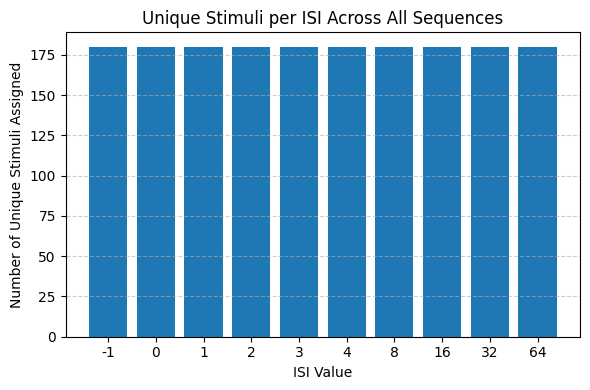

In [87]:
sm.check_unique_stimuli_per_isi();

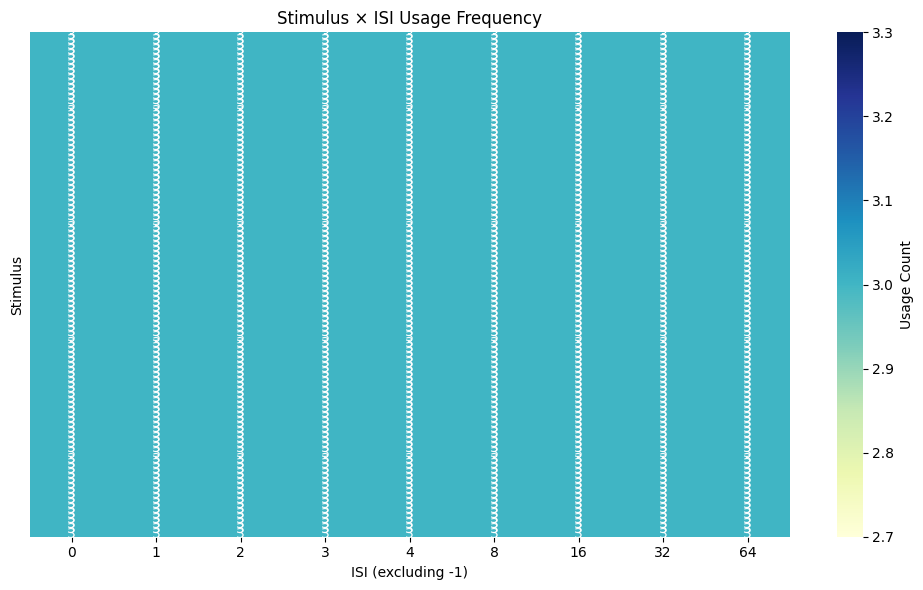

In [88]:
sm.plot_stimulus_isi_usage(max_stimuli=100)

In [ ]:
manager.plot_summary()

In [ ]:
manager.plot_avg_isi_across_sequences()

In [ ]:
manager.plot_avg_position_of_repeats()

In [ ]:
manager.plot_isi_position_bias(bins=5)

In [ ]:
manager.plot_isi_temporal_spread(bins=5)

In [ ]:
manager.plot_repetition_rate_per_sequence()

In [ ]:
sm.plot_stimulus_isi_usage()

In [ ]:
manager.check_for_duplicate_sequences()

In [ ]:
for pair in manager.pairs:
    for isi in pair:
        sorted(pair[isi])

In [ ]:
for d in manager.pairs:
    for key in d:
        d[key] = sorted(d[key])